### TfIdf with feature selection

Inspired by [tf-idf-spark-and-python](https://github.com/logicalguess/tf-idf-spark-and-python/tree/master)

In [1]:
import pandas as pd
import sys
import os

sys.path.append(os.path.abspath("../src"))

In [14]:
labeled_df = pd.read_csv('../data/labeledTrainData.tsv.zip', header=0, delimiter="\t", quoting=3)
unlabeled_df = pd.read_csv('../data/unlabeledTrainData.tsv.zip', header=0, delimiter="\t", quoting=3)
test_df = pd.read_csv('../data/testData.tsv.zip', header=0, delimiter="\t", quoting=3)

print(f"labeled_df shape: {labeled_df.shape}")
print(f"unlabeled_df shape: {unlabeled_df.shape}")
print(f"test_df shape: {test_df.shape}")

labeled_df shape: (25000, 3)
unlabeled_df shape: (50000, 2)
test_df shape: (25000, 2)


In [15]:
import my_utils # noqa: F401

wordlist_labeled_train = labeled_df.review.nlp.review_to_wordlist()
wordlist_unlabeled_train = unlabeled_df.review.nlp.review_to_wordlist()
wordlist_test = test_df.review.nlp.review_to_wordlist()

print(f"wordlist_labeled_train shape: {wordlist_labeled_train.shape}")
print(f"wordlist_unlabeled_train shape: {wordlist_unlabeled_train.shape}")
print(f"wordlist_test shape: {wordlist_test.shape}")

wordlist_all =  pd.concat([wordlist_labeled_train, wordlist_unlabeled_train], ignore_index=True)
corpus_all = [' '.join(w) for w in wordlist_all.tolist()]
corpus_train = [' '.join(w) for w in wordlist_labeled_train.tolist()]
corpus_test = [' '.join(w) for w in wordlist_test.tolist()]

print(f"Total number of reviews in corpus_all: {len(corpus_all)}")
print(f"Total number of reviews in corpus_train: {len(corpus_train)}")
print(f"Total number of reviews in corpus_test: {len(corpus_test)}")

wordlist_labeled_train shape: (25000,)
wordlist_unlabeled_train shape: (50000,)
wordlist_test shape: (25000,)
Total number of reviews in corpus_all: 75000
Total number of reviews in corpus_train: 25000
Total number of reviews in corpus_test: 25000


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_df=0.85)
vectorizer = vectorizer.fit(corpus_all)
tfidf_matrix = vectorizer.transform(corpus_train)

print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

Vocabulary size: 123129
TF-IDF matrix shape: (25000, 123129)


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2


fselect = SelectKBest(chi2, k=7000)
train_data_features = fselect.fit_transform(tfidf_matrix, labeled_df.sentiment)
train_data_features.shape


X_train, X_test, y_train, y_test = train_test_split(
    train_data_features, labeled_df.sentiment, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((20000, 7000), (5000, 7000), (20000,), (5000,))

In [6]:
from sklearn.svm import LinearSVC


clf = LinearSVC(random_state=42, max_iter=1000)
clf.fit(X_train, y_train)
score = clf.score(X_test, y_test)
print(f'LinearSVC sentiment score: {score}')

LinearSVC sentiment score: 0.9032


In [ ]:
from sklearn.metrics import auc, roc_curve

# decision_function outputs raw, unbounded distances from the separating hyperplane, not probabilities.
scores = clf.decision_function(X_test)
fpr, tpr, thresholds = roc_curve(y_test, scores)
roc_auc = auc(fpr, tpr)

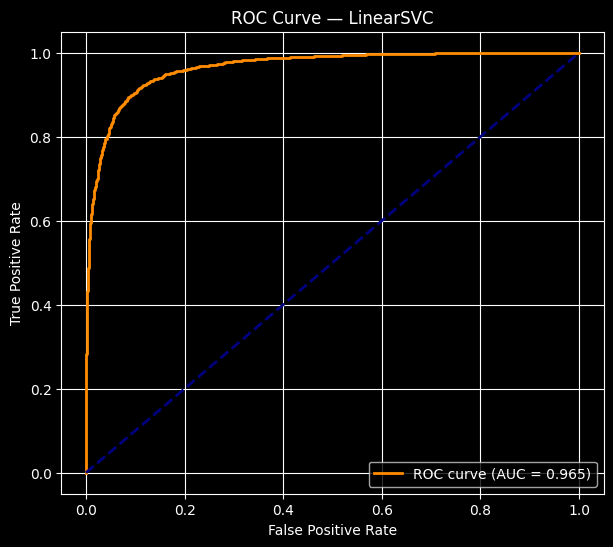

In [12]:
# Plot
from matplotlib import pyplot as plt


plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — LinearSVC")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [19]:
X_test_final = fselect.transform(vectorizer.transform(corpus_test))
X_test_final.shape

(25000, 7000)

In [22]:
y_final = clf.predict(X_test_final)
y_final.shape

(25000,)

In [ ]:
test_df['sentiment'] = y_final
test_df = test_df[['id', 'sentiment']]
test_df.to_csv('../data/results/word2vec.200_linearcvc.result.csv', index=False,  quoting=3,  escapechar='\\')